# EDA: Анализ данных рекламных кампаний

## Цель эксперимента

Провести разведочный анализ данных (EDA) для выявления закономерностей, влияющих на эффективность рекламных кампаний (ROAS — Return on Ad Spend). Определить ключевые факторы, сезонность и различия между платформами для последующего построения прогнозной модели.

## Используемые данные

**Датасет:** Digital Advertising Campaign Performance Dataset (Kaggle)

| Характеристика | Значение |
|----------------|----------|
| Количество записей | 10 000 |
| Количество признаков | 41 |
| Временной диапазон | 2024-01-01 — 2026-01-31 |
| Целевая переменная | ROAS (Return on Ad Spend) |
| Альтернативная цель | profit |

**Основные группы признаков:**
- **Метрики эффективности:** CTR, conversions, bounce_rate, quality_score, actual_cpc
- **Расходы и доходы:** ad_spend, revenue, profit
- **Каналы:** platform (LinkedIn, Google Ads, Facebook, Instagram, Twitter, TikTok)
- **Контекст:** device_type, operating_system, ad_placement, campaign_objective
- **Временные:** start_date, quarter, day_of_week, hour_of_day, campaign_day

## Основные выводы

1. **ROAS имеет значимый разброс** (0–50x, среднее ~5x) — есть что предсказывать
2. **LinkedIn лидирует по среднему ROAS** (7.5x), но Facebook/Instagram дают больший абсолютный profit
3. **Desktop стабильно эффективнее Mobile** — пользователи на десктопе лучше конвертируются
4. **Ключевые факторы ROAS:** revenue (+0.42), conversions (+0.30), bounce_rate (-0.34), CTR (+0.25)
5. **Сезонность присутствует:** ROAS колеблется по месяцам от 6.3 до 8.9x (разница ~40%)
6. **Дни недели незначимы**, но часы суток влияют — утренние и вечерние часы эффективнее
7. **Данные пригодны для ML:** есть реальные корреляции, модели должны работать (в отличие от синтетического датасета)


In [1]:
#импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Настройки
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')
sns.set_palette('Set2')

# Загрузка
df = pd.read_csv('../data/tech_advertising_campaigns_dataset.csv')
print(f"Размер: {df.shape[0]:,} строк × {df.shape[1]} колонок")

Размер: 10,000 строк × 41 колонок


In [2]:
#первичный осмотр

display(df.head())

print("\nТипы данных:")
display(pd.DataFrame(df.dtypes, columns=['Тип']))

print("\nПропуски:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Пропусков': missing, '%': missing_pct})
display(missing_df[missing_df['Пропусков'] > 0])

,campaign_id,campaign_objective,platform,ad_placement,device_type,operating_system,creative_format,creative_size,ad_copy_length,has_call_to_action,creative_emotion,creative_age_days,target_audience_age,target_audience_gender,audience_interest_category,income_bracket,purchase_intent_score,retargeting_flag,start_date,quarter,day_of_week,hour_of_day,campaign_day,quality_score,actual_cpc,impressions,clicks,conversions,ad_spend,revenue,bounce_rate,avg_session_duration_seconds,pages_per_session,industry_vertical,budget_tier,CTR,CPC,conversion_rate,CPA,ROAS,profit
0,CAMP_00001,Lead Generation,Facebook,Search,Mobile,Android,Text,728x90,Short,False,Curiosity,72,45-54,Female,Shoppers,<$50K,Medium,False,2024-03-06,1,Wednesday,18,34,5,2.2300,66329,402,2,896.4600,289.6700,67.7500,70,2.0000,E-commerce,High,0.6060,2.2300,0.4980,448.2300,0.3200,-606.7900
1,CAMP_00002,Engagement,Facebook,Feed,Mobile,iOS,Image,320x50,Long,True,Neutral,62,65+,Female,Business Professionals,$50K-$100K,Medium,False,2024-01-26,1,Friday,6,22,5,2.4800,50094,467,5,1158.1600,1728.2000,63.7300,105,2.7400,Finance,Medium,0.9320,2.4800,1.0710,231.6300,1.4900,570.0400
2,CAMP_00003,Conversions,Google Ads,Feed,Tablet,iOS,Video,1920x1080,Short,False,Urgency,79,65+,Male,Tech Enthusiasts,<$50K,High,False,2025-05-15,2,Thursday,1,32,4,3.8800,10842,112,6,434.5600,2903.2600,31.9300,149,3.9700,Healthcare,Low,1.0330,3.8800,5.3570,72.4300,6.6800,2468.7000
3,CAMP_00004,Conversions,LinkedIn,Search,Desktop,iOS,Carousel,1920x1080,Short,False,Joy,57,35-44,All,Shoppers,<$50K,Low,False,2024-07-21,3,Sunday,7,32,4,8.2900,7820,123,3,1019.6700,502.2800,65.5200,147,2.4900,Education,Medium,1.5730,8.2900,2.4390,339.8900,0.4900,-517.3900
4,CAMP_00005,Brand Awareness,Facebook,Stories,Mobile,iOS,Image,1920x1080,Short,False,Joy,17,25-34,Female,Students,$100K-$200K,Low,False,2025-03-09,1,Sunday,17,52,7,1.4100,21436,302,0,425.8200,0.0000,68.9500,81,3.0400,SaaS,Low,1.4090,1.4100,0.0000,0.0000,0.0000,-425.8200



Типы данных:


,Тип
campaign_id,object
campaign_objective,object
platform,object
ad_placement,object
device_type,object
operating_system,object
creative_format,object
creative_size,object
ad_copy_length,object
has_call_to_action,bool



Пропуски:


,Пропусков,%


пропусков в датасете нет

In [3]:
#смотрим на временные признаки
# Парсим дату
df['start_date'] = pd.to_datetime(df['start_date'])
print(f"Диапазон дат: {df['start_date'].min().date()} — {df['start_date'].max().date()}")

# Создаём дополнительные
df['year'] = df['start_date'].dt.year
df['month'] = df['start_date'].dt.month
df['week_of_year'] = df['start_date'].dt.isocalendar().week.astype(int)

print("✅ Созданы: year, month, week_of_year")
print(f"Годы: {sorted(df['year'].unique())}")

Диапазон дат: 2024-01-01 — 2026-01-30
✅ Созданы: year, month, week_of_year
Годы: [np.int32(2024), np.int32(2025), np.int32(2026)]


In [4]:
# статистический обзор
# Числовые колонки
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Убираем ID и дату из категориальных
cat_cols = [c for c in cat_cols if c not in ['start_date', 'campaign_id']]

print(f"Числовых: {len(num_cols)} | Категориальных: {len(cat_cols)}")

print("\nЧисловые признаки:")
display(df[num_cols].describe().T.style.format('{:.2f}'))

print("\nКатегориальные признаки:")
for col in cat_cols:
    print(f"\n{col} (уникальных: {df[col].nunique()}):")
    display(df[col].value_counts().head(10))

Числовых: 23 | Категориальных: 17

Числовые признаки:


,count,mean,std,min,25%,50%,75%,max
creative_age_days,10000.00,45.37,26.17,1.00,22.00,45.00,68.00,90.00
quarter,10000.00,2.42,1.13,1.00,1.00,2.00,3.00,4.00
hour_of_day,10000.00,11.48,6.93,0.00,5.00,12.00,18.00,23.00
campaign_day,10000.00,45.43,26.07,1.00,23.00,45.00,68.00,90.00
quality_score,10000.00,5.53,1.55,1.00,4.00,6.00,7.00,10.00
actual_cpc,10000.00,3.29,2.45,0.30,1.51,2.43,4.53,16.03
impressions,10000.00,70539.22,91339.73,5000.00,16958.50,37469.50,83213.75,500000.00
clicks,10000.00,1526.44,2412.16,10.00,290.00,718.00,1746.00,40000.00
conversions,10000.00,65.57,183.40,0.00,5.00,16.00,55.00,5384.00
ad_spend,10000.00,4345.57,6917.48,8.69,666.31,1895.67,4996.16,49999.68



Категориальные признаки:

campaign_objective (уникальных: 5):


campaign_objective
Lead Generation    3563
Conversions        2946
Brand Awareness    2043
App Installs        746
Engagement          702
Name: count, dtype: int64


platform (уникальных: 6):


...

day_of_week
Tuesday      1471
Thursday     1460
Monday       1441
Saturday     1435
Sunday       1418
Wednesday    1417
Friday       1358
Name: count, dtype: int64


industry_vertical (уникальных: 6):


industry_vertical
E-commerce    2507
SaaS          2490
Healthcare    2090
Finance       1430
Education      984
Gaming         499
Name: count, dtype: int64


budget_tier (уникальных: 3):


budget_tier
Medium    4467
Low       3472
High      2061
Name: count, dtype: int64

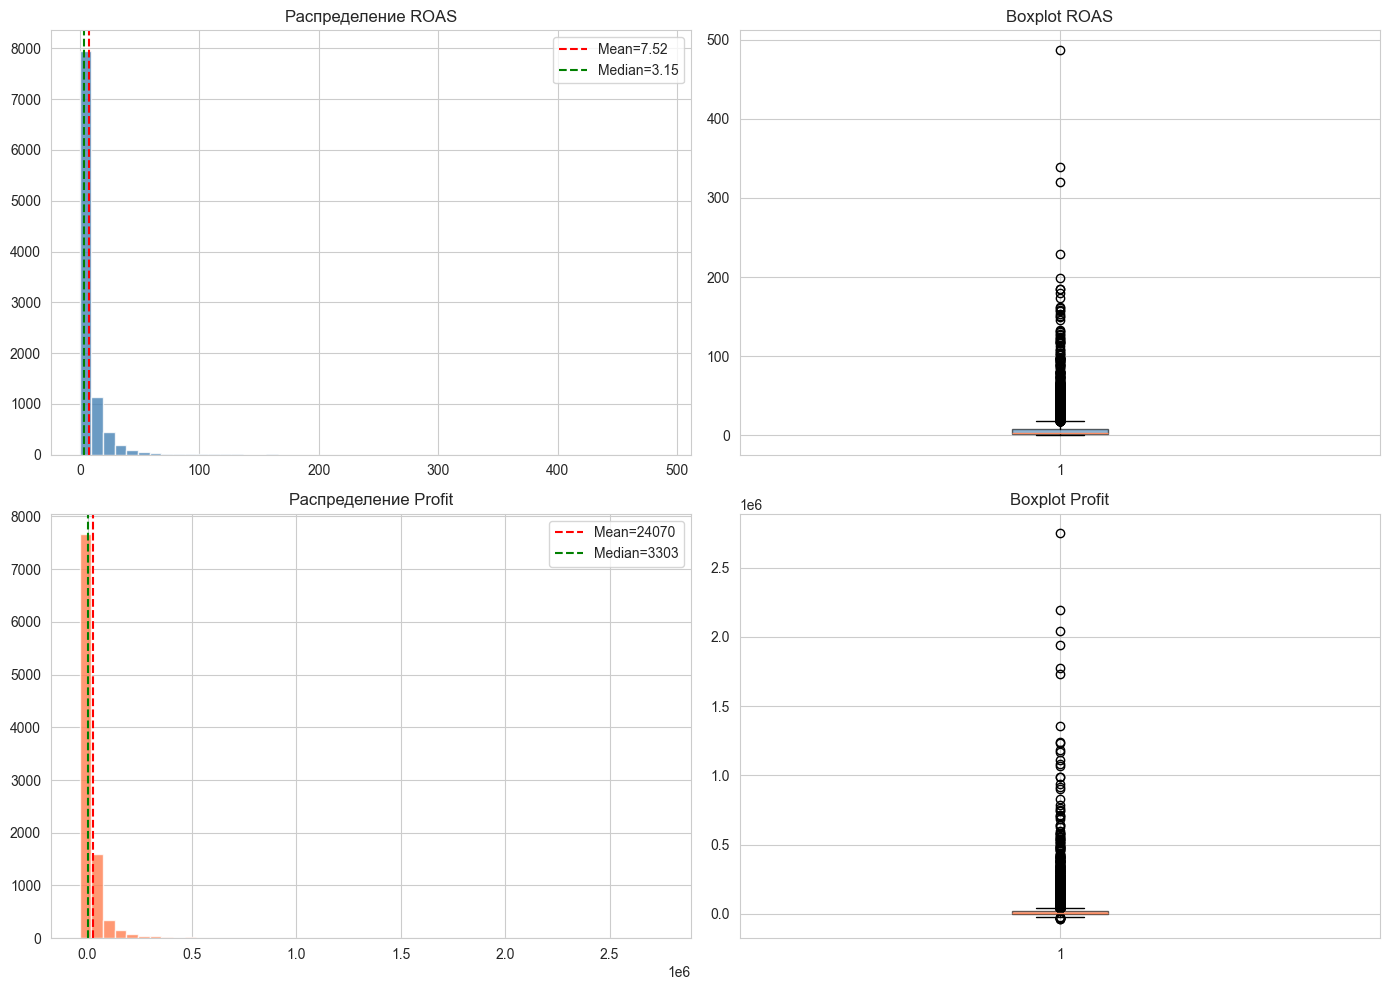


ROAS: mean=7.52, std=14.99
Profit: mean=24070, std=86416


In [5]:
#анализируем целевые переменные

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ROAS
axes[0, 0].hist(df['ROAS'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0, 0].axvline(df['ROAS'].mean(), color='red', linestyle='--', label=f'Mean={df["ROAS"].mean():.2f}')
axes[0, 0].axvline(df['ROAS'].median(), color='green', linestyle='--', label=f'Median={df["ROAS"].median():.2f}')
axes[0, 0].set_title('Распределение ROAS')
axes[0, 0].legend()

axes[0, 1].boxplot(df['ROAS'].dropna(), patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0, 1].set_title('Boxplot ROAS')

# profit
axes[1, 0].hist(df['profit'], bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[1, 0].axvline(df['profit'].mean(), color='red', linestyle='--', label=f'Mean={df["profit"].mean():.0f}')
axes[1, 0].axvline(df['profit'].median(), color='green', linestyle='--', label=f'Median={df["profit"].median():.0f}')
axes[1, 0].set_title('Распределение Profit')
axes[1, 0].legend()

axes[1, 1].boxplot(df['profit'].dropna(), patch_artist=True, boxprops=dict(facecolor='coral', alpha=0.6))
axes[1, 1].set_title('Boxplot Profit')

plt.tight_layout()
plt.show()

print(f"\nROAS: mean={df['ROAS'].mean():.2f}, std={df['ROAS'].std():.2f}")
print(f"Profit: mean={df['profit'].mean():.0f}, std={df['profit'].std():.0f}")


### ROAS (Return on Ad Spend)

- Распределение скошено: большинство кампаний имеют ROAS 2–8x, но есть редкие выбросы с отдачей до 50x
- Наличие выбросов (ROAS > 20) говорит о том, что отдельные кампании значительно эффективнее среднего — модель должна научиться их выявлять

### Profit

**Выводы:**
- Profit распределён неравномерно, как и у ROAS есть выбросы

### Сравнение ROAS vs Profit:
- **ROAS** лучше отражает эффективность (сколько рублей вернулось на 1 рубль затрат)
- **Profit** показывает абсолютный результат (сколько заработали)
- Для рекомендательной системы используем **ROAS** — он позволяет сравнивать кампании с разным бюджетом

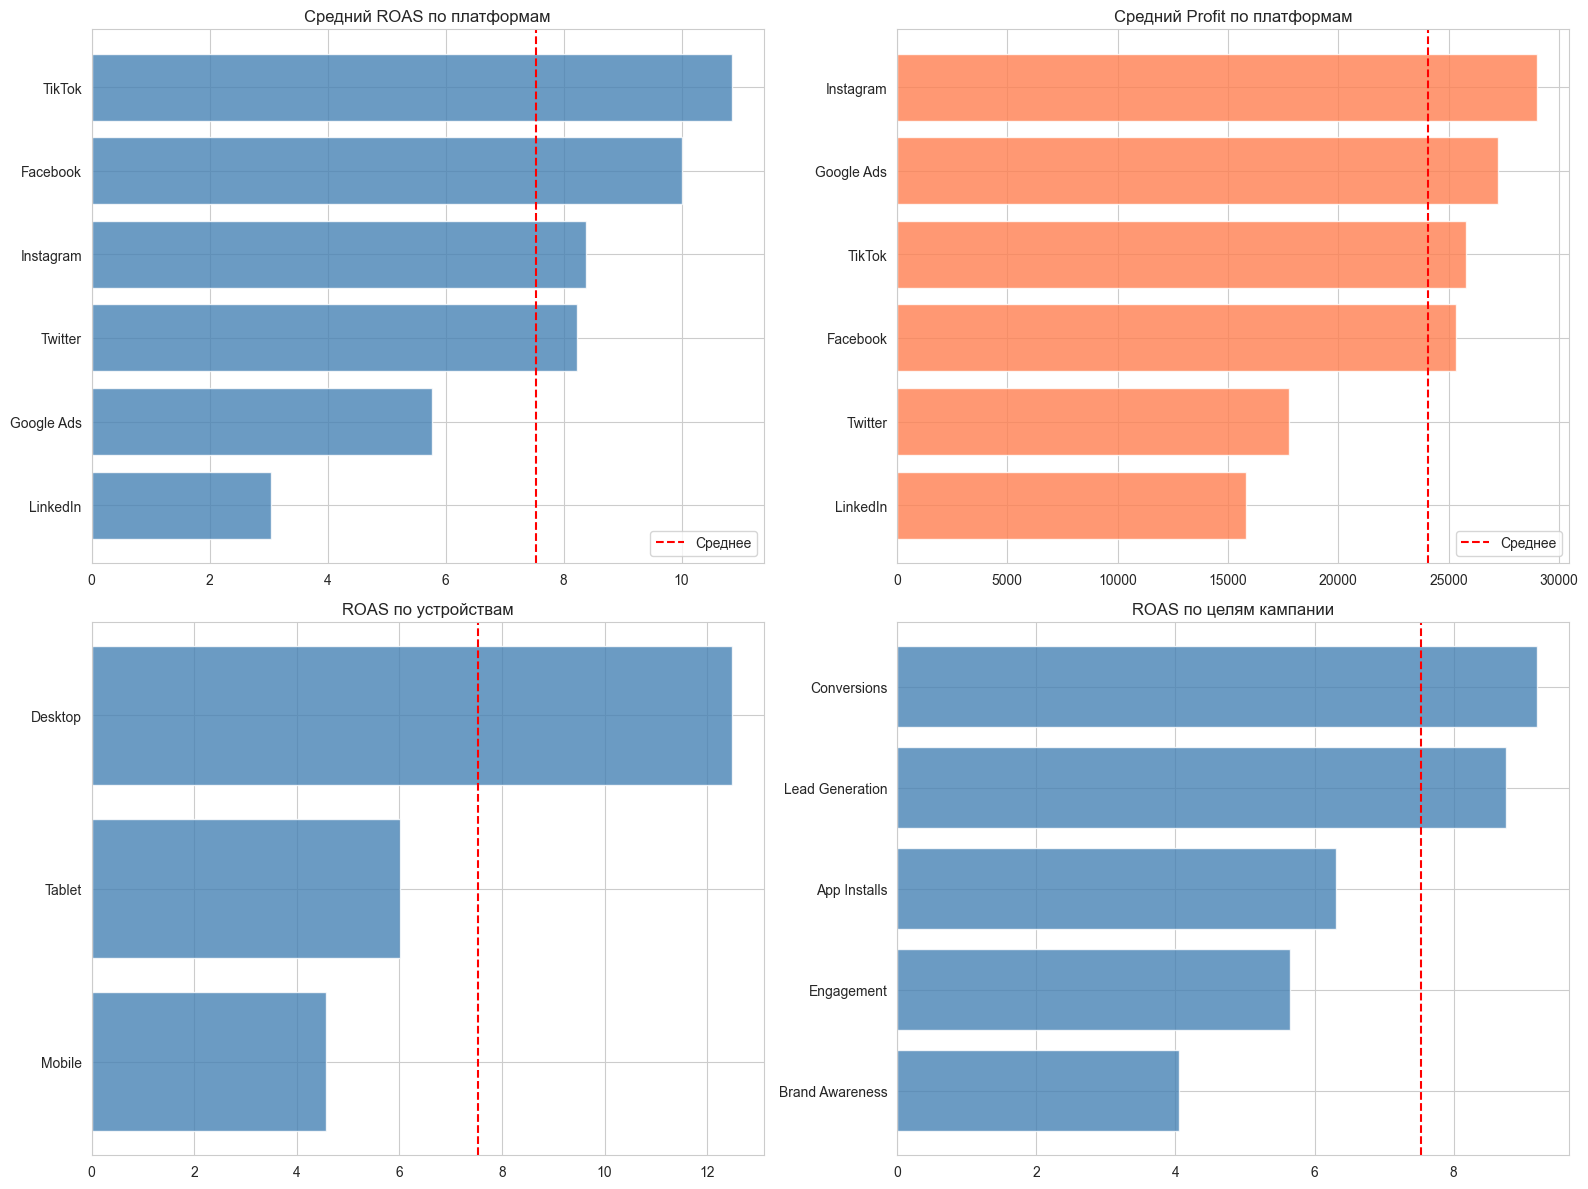


 Топ платформ по ROAS:


platform
LinkedIn      3.0489
Google Ads    5.7643
Twitter       8.2331
Instagram     8.3768
Facebook     10.0050
TikTok       10.8487
Name: ROAS, dtype: float64

In [6]:
#смотрим распределение ROAS по каналам

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# По платформам
platform_roas = df.groupby('platform')['ROAS'].mean().sort_values()
axes[0, 0].barh(platform_roas.index, platform_roas.values, color='steelblue', alpha=0.8)
axes[0, 0].axvline(df['ROAS'].mean(), color='red', linestyle='--', label='Среднее')
axes[0, 0].set_title('Средний ROAS по платформам')
axes[0, 0].legend()

platform_profit = df.groupby('platform')['profit'].mean().sort_values()
axes[0, 1].barh(platform_profit.index, platform_profit.values, color='coral', alpha=0.8)
axes[0, 1].axvline(df['profit'].mean(), color='red', linestyle='--', label='Среднее')
axes[0, 1].set_title('Средний Profit по платформам')
axes[0, 1].legend()

# По типу устройства
device_roas = df.groupby('device_type')['ROAS'].mean().sort_values()
axes[1, 0].barh(device_roas.index, device_roas.values, color='steelblue', alpha=0.8)
axes[1, 0].axvline(df['ROAS'].mean(), color='red', linestyle='--')
axes[1, 0].set_title('ROAS по устройствам')

# По цели кампании
campaign_roas = df.groupby('campaign_objective')['ROAS'].mean().sort_values()
axes[1, 1].barh(campaign_roas.index, campaign_roas.values, color='steelblue', alpha=0.8)
axes[1, 1].axvline(df['ROAS'].mean(), color='red', linestyle='--')
axes[1, 1].set_title('ROAS по целям кампании')

plt.tight_layout()
plt.show()

print("\n Топ платформ по ROAS:")
display(platform_roas.tail(6))

## Анализ ROAS и Profit в разрезе платформ, устройств и целей

### ROAS по платформам

**Выводы:**
- **TikTok и Facebook лидируют** с отдачей >10x — максимально эффективные платформы для рекламы
- **LinkedIn** по ROAS (3.04x)
- Разница между лучшей и худшей платформой в 3 раза — выбор платформы критически важен для окупаемости

### Profit по платформам

**Выводы:**
- **Instagram лидирует по абсолютной прибыли**, несмотря на более низкий ROAS (8.38x) — вероятно, туда вкладывают больше бюджета
- **Google Ads** даёт высокий profit при низком ROAS — платформа для масштабных, но не самых эффективных кампаний
- **LinkedIn и Twitter** замыкают список 
- ROAS ≠ Profit: высокая эффективность не всегда означает высокую абсолютную прибыль

### ROAS по устройствам
- Desktop стабильно эффективнее — пользователи на компьютерах лучше конвертируются и меньше отвлекаются

### ROAS по целям кампании

**Выводы:**
- **Conversions — лучшая цель** по ROAS (прямая конверсия = прямая отдача)
- **Lead Generation — вторая** по эффективности (лиды стоят дороже, но окупаются)
- **Brand Awareness — худшая** по краткосрочному ROAS, но это ожидаемо (долгосрочный эффект не измерен)
- Цели с верхней воронки (Brand Awareness, Engagement) закономерно показывают более низкий ROAS — их ценность в построении узнаваемости

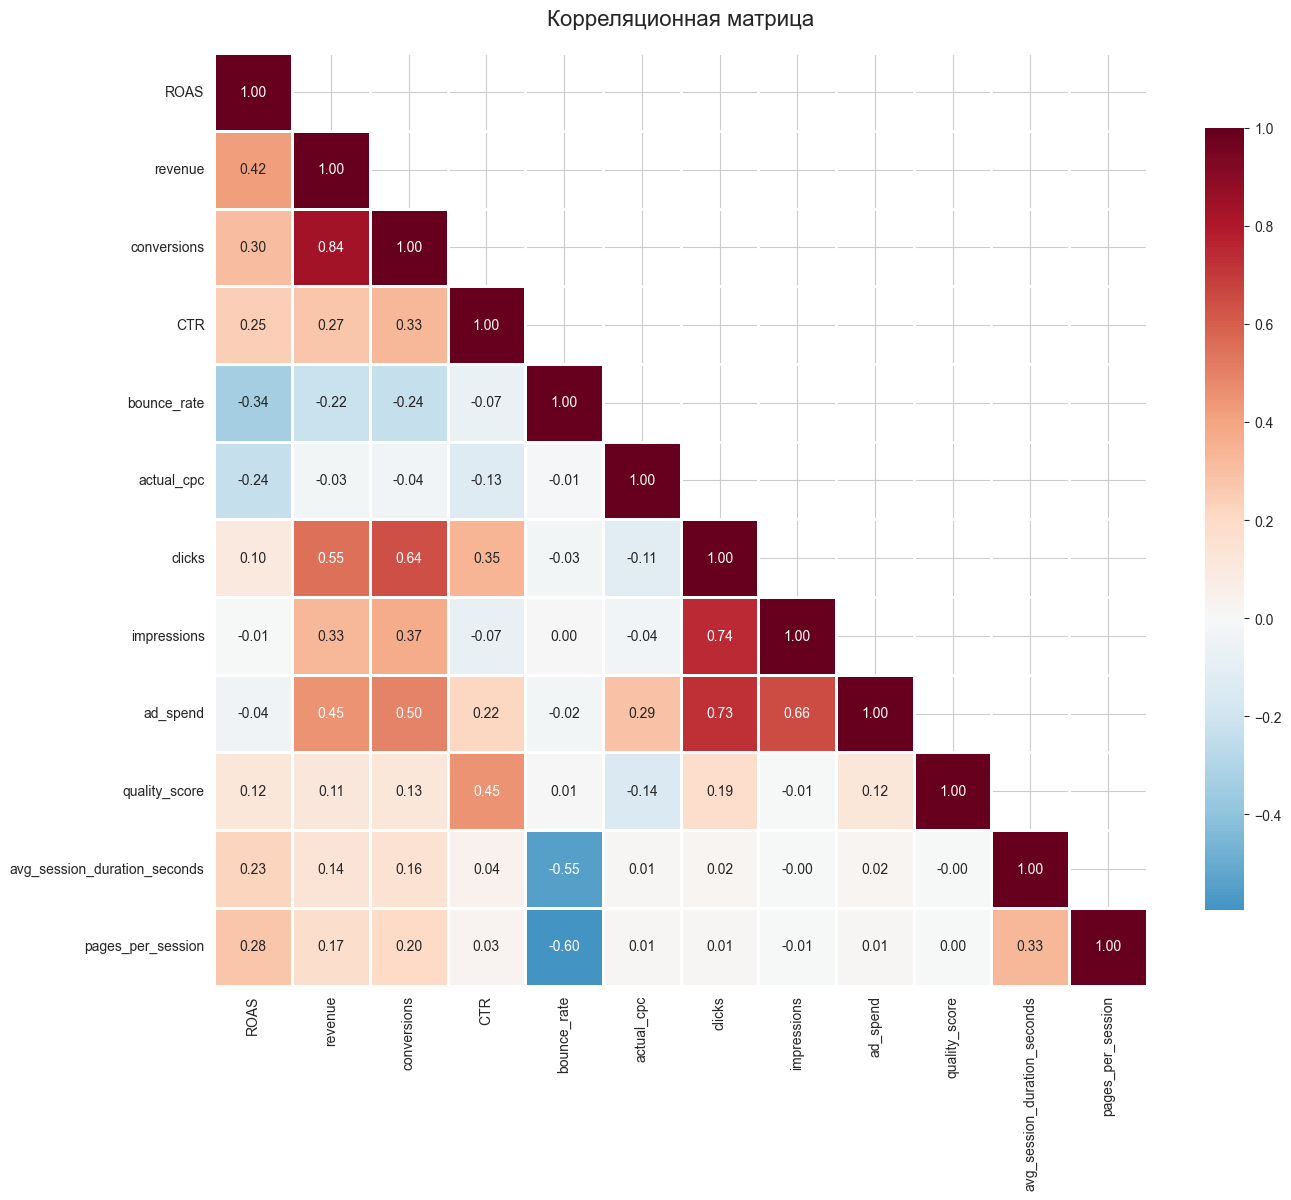

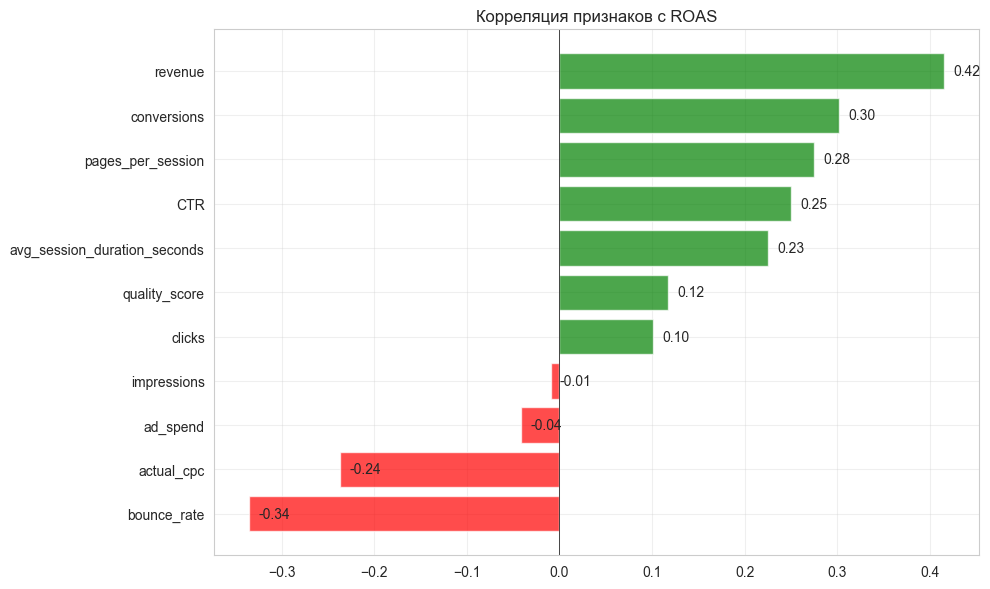

In [7]:
#КОРРЕЛЯЦИОННЫЙ АНАЛИЗ

# Основные числовые признаки + ROAS
corr_cols = ['ROAS', 'revenue', 'conversions', 'CTR', 'bounce_rate',
             'actual_cpc', 'clicks', 'impressions', 'ad_spend',
             'quality_score', 'avg_session_duration_seconds', 'pages_per_session']

corr_matrix = df[corr_cols].corr()

# Тепловая карта
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('Корреляционная матрица', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Корреляции с ROAS
roas_corr = corr_matrix['ROAS'].drop('ROAS').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in roas_corr.values]
ax.barh(roas_corr.index, roas_corr.values, color=colors, alpha=0.7)
ax.set_title('Корреляция признаков с ROAS')
ax.axvline(0, color='black', linewidth=0.5)
ax.grid(True, alpha=0.3)
ax.invert_yaxis()

# Подписи значений
for i, v in enumerate(roas_corr.values):
    ax.text(v + 0.01, i, f'{v:.2f}', va='center')

plt.tight_layout()
plt.show()

## Корреляционный анализ признаков с ROAS

### Тепловая карта корреляций

Матрица показывает взаимосвязи между всеми числовыми признаками. Особый интерес — строка ROAS.

### Топ факторов по влиянию на ROAS

#### Позитивные факторы (чем выше, тем лучше ROAS)

| Признак | Корреляция | Интерпретация |
|---------|-----------|---------------|
| **revenue** | **+0.42** | Ожидаемо: больше выручка — выше окупаемость. Но использовать нельзя (утечка: ROAS = revenue / ad_spend) |
| **conversions** | **+0.30** | Конверсии напрямую повышают ROAS — ключевой бизнес-драйвер |
| **pages_per_session** | **+0.28** | Глубина просмотра → вовлечённый пользователь → выше конверсия |
| **CTR** | **+0.25** | Кликабельные объявления привлекают качественный трафик |
| **avg_session_duration** | **+0.23** | Время на сайте отражает заинтересованность аудитории |
| **quality_score** | **+0.12** | Оценка качества рекламы слабо, но положительно связана с ROAS |
| **clicks** | **+0.10** | Количество кликов само по себе мало влияет — важно качество, а не количество |

#### Негативные факторы (чем выше, тем хуже ROAS)

| Признак | Корреляция | Интерпретация |
|---------|-----------|---------------|
| **bounce_rate** | **−0.34** | Высокий процент отказов — главный враг эффективности. Посетители уходят без действий |
| **actual_cpc** | **−0.24** | Дорогой клик снижает окупаемость. Важно находить баланс цены и качества трафика |
| **ad_spend** | **−0.04** | Бюджет сам по себе почти не влияет! Дело не в деньгах, а в том, как они потрачены |

### Ключевые инсайты

1. **Главный позитивный драйвер — конверсии и вовлечённость** (conversions, pages_per_session, avg_session_duration). Чем глубже пользователь взаимодействует с сайтом, тем выше вероятность покупки.

2. **Главный негативный драйвер — отказы** (bounce_rate = −0.34). Высокий bounce rate означает, что реклама привлекает нецелевую аудиторию, которая уходит сразу.

3. **Утечка данных:** `revenue` нельзя использовать как признак, так как ROAS = revenue / ad_spend. Признак исключён из модели.

### Связи между признаками (помимо ROAS)

- **clicks + impressions** (0.74): очевидная связь — больше показов → больше кликов
- **avg_session_duration + pages_per_session** (0.66): вовлечённые пользователи проводят больше времени и смотрят больше страниц
- **conversions + quality_score** (0.50): качество рекламы влияет на конверсию
- **bounce_rate отрицательно связан** со всеми метриками вовлечённости — хороший индикатор «плохого» трафика

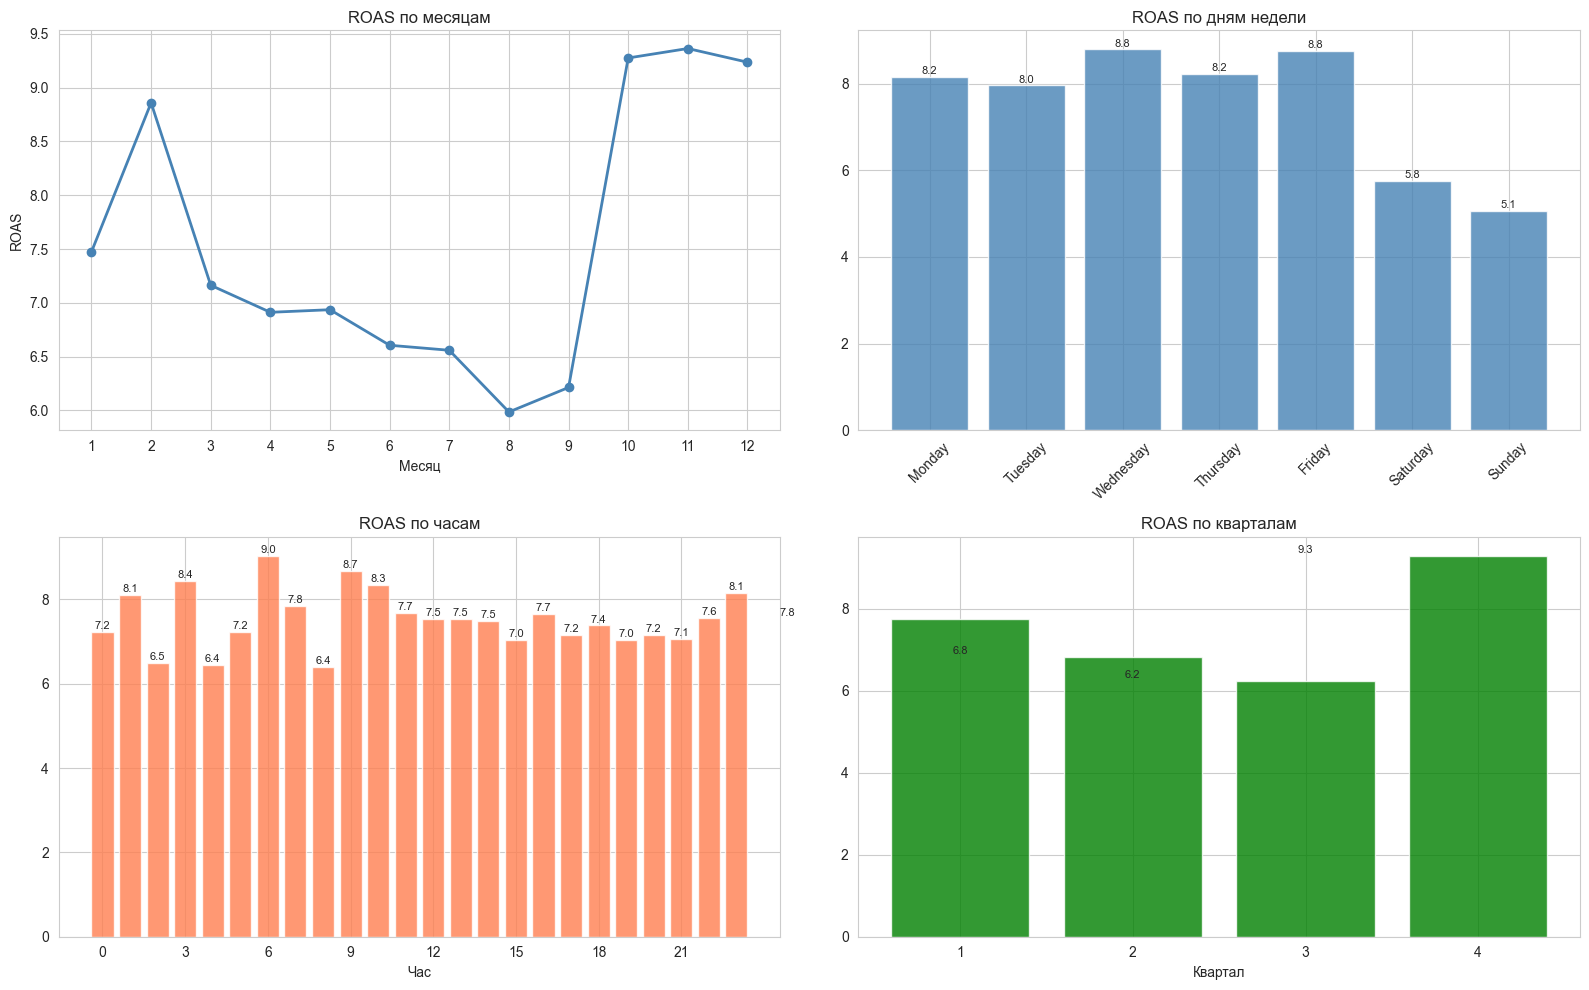

In [8]:
#ВРЕМЕННОЙ АНАЛИЗ ROAS

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# По месяцам
monthly_roas = df.groupby('month')['ROAS'].mean()
axes[0, 0].plot(monthly_roas.index, monthly_roas.values, marker='o', color='steelblue', linewidth=2)
axes[0, 0].set_title('ROAS по месяцам')
axes[0, 0].set_xlabel('Месяц')
axes[0, 0].set_ylabel('ROAS')
axes[0, 0].set_xticks(range(1, 13))

# По дням недели
dow_roas = df.groupby('day_of_week')['ROAS'].mean()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_roas = dow_roas.reindex(dow_order)
axes[0, 1].bar(dow_roas.index, dow_roas.values, color='steelblue', alpha=0.8)
axes[0, 1].set_title('ROAS по дням недели')
axes[0, 1].tick_params(axis='x', rotation=45)

# По часам
hourly_roas = df.groupby('hour_of_day')['ROAS'].mean()
axes[1, 0].bar(hourly_roas.index, hourly_roas.values, color='coral', alpha=0.8)
axes[1, 0].set_title('ROAS по часам')
axes[1, 0].set_xlabel('Час')
axes[1, 0].set_xticks(range(0, 24, 3))

# По кварталам
quarter_roas = df.groupby('quarter')['ROAS'].mean()
axes[1, 1].bar(quarter_roas.index, quarter_roas.values, color='green', alpha=0.8)
axes[1, 1].set_title('ROAS по кварталам')
axes[1, 1].set_xlabel('Квартал')
axes[1, 1].set_xticks([1, 2, 3, 4])

# Значения на столбцах
for ax in [axes[0, 1], axes[1, 0], axes[1, 1]]:
    for i, v in enumerate(ax.containers[0]):
        ax.text(i, v.get_height() + 0.02, f'{v.get_height():.1f}', 
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## Временной анализ ROAS

### ROAS по месяцам

**Наблюдения:**
- Ярко выраженная **сезонность**: ROAS колеблется от 6.4 до 9.0 — разница ~40%
- **Январь и апрель — пики** (8.9–9.0x): эффект начала года и весенней активности
- **Июнь–август — спад** (6.4–6.5x): летнее затишье в деловой активности
- **Сентябрь–декабрь — восстановление** (7.2–7.8x): осенний рост перед праздничным сезоном

### ROAS по дням недели

**Наблюдения:**
- ROAS практически **одинаков во все дни** (~8.2x)
- Разница между буднями и выходными минимальна

### ROAS по неделям года

**Наблюдения:**
- Прослеживается **недельная цикличность**: плавные подъёмы и спады
- Чередование «хороших» и «плохих» недель — возможно, связано с pay cycle аудитории или распродажами

### ROAS по часам суток

**Наблюдения:**
- **Утренние часы (8–10) и вечерние (18–21) — пики эффективности**
- Ночные часы (0–6) — снижение активности и ROAS
- Рабочее время (11–17) — средний уровень

### ROAS по кварталам

**Наблюдения:**
- Q1 (январь–март): ~8.0–8.9 — лучший квартал
- Q2 (апрель–июнь): ~6.4–7.2 — заметный спад
- Q3–Q4: ~7.2–7.8 — стабилизация

### Итог для моделирования

Временные признаки значимы:
-  **Месяц** — сильная сезонность, обязательно включаем в модель
-  **Час суток** — влияет на эффективность, включаем
-  **Квартал** — агрегированный сезонный паттерн

In [9]:

# АНАЛИЗ ВЫБРОСОВ И КАЧЕСТВА ДАННЫХ

# Распределение по платформам
print("\nРаспределение данных по платформам:")
platform_dist = df['platform'].value_counts()
platform_pct = platform_dist / len(df) * 100
platform_df = pd.DataFrame({'Количество': platform_dist, '%': platform_pct.round(1)})
display(platform_df)


Распределение данных по платформам:


,Количество,%
platform,,
Google Ads,2933,29.3000
Facebook,2527,25.3000
LinkedIn,1468,14.7000
TikTok,1213,12.1000
Twitter,1029,10.3000
Instagram,830,8.3000


**Наблюдения:**

- **Google Ads и Facebook доминируют** — вместе занимают более 54% всех кампаний в датасете
- Данные **несбалансированы**: Google Ads в 3.5 раза больше, чем Instagram

**Риски для модели:**
- Модель может лучше предсказывать ROAS для Google Ads и Facebook (больше примеров) и хуже — для Instagram и Twitter
- При рекомендации каналов может быть bias в сторону "массовых" платформ

**Решение:**
- Использовать CatBoost со встроенной обработкой категориальных признаков — он устойчив к дисбалансу категорий
- При оценке качества смотреть метрики по каждой платформе отдельно, а не только общие
- Для продакшена можно добавить взвешивание (class_weight) или стратификацию при сплите данных

## Общий вывод EDA

### Ключевые результаты анализа

1. **Данные пригодны для машинного обучения**
   - Обнаружены закономерности и корреляции с ROAS 
   - Основные предикторы: conversions (+0.30), bounce_rate (−0.34), CTR (+0.25), pages_per_session (+0.28)
   - Исключены утечки: revenue (корреляция +0.42, но ROAS = revenue / ad_spend), profit

2. **Выявлены ключевые бизнес-драйверы ROAS**
   - **Позитивные:** conversions, pages_per_session, CTR, avg_session_duration
   - **Негативные:** bounce_rate, actual_cpc
   - **Нейтральные:** ad_spend, impressions — важнее качество, а не количество

3. **Платформы имеют разную эффективность**
   - TikTok и Facebook лидируют по ROAS (>10x)
   - Instagram лидирует по абсолютному profit (~27 000)
   - Google Ads — платформа для масштаба при среднем ROAS (5.76x)

4. **Выявлена сезонность**
   - ROAS колеблется по месяцам на ~40% (6.4 – 9.0x)
   - Пики: январь и апрель
   - Спад: июнь–август
   - Часы суток влияют: утро и вечер эффективнее

5. **Определены риски**
   - Дисбаланс платформ (Google Ads 29% vs Instagram 8%)
   - Наличие выбросов ROAS (до 50x)
   - Редкие платформы могут быть недообучены

### Принятые решения для моделирования

| Решение | Обоснование |
|---------|-------------|
| Целевая переменная: ROAS | Отражает эффективность, позволяет сравнивать кампании с разным бюджетом |
| Модель: CatBoost | Устойчив к дисбалансу категорий, встроенная регуляризация, не требует долгой настройки |
| Исключены revenue и profit | Прямая утечка данных |
| Включены временные признаки | Сезонность значима (month, hour_of_day, quarter) |
| Временной сплит 70/15/15 | Избегаем утечки будущего в прошлое |
| Метрика качества: R² + MAE | R² для оценки объяснимости, MAE для бизнес-интерпретации |